In [16]:
import os
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import shapely

from pygam import LogisticGAM, s, f
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, f1_score,
    balanced_accuracy_score, average_precision_score
)

# ============================================================
# PAQUETE C
# - NO: lugar distinto (>min_dist_m) y fecha distinta (fuera ±excl_days)
# - NO: umbrales mínimos 1d,7d,90d
# - Variables: T,P,sin_doy,cos_doy,ENSO,geologia,cobertura,pendiente,log_area
# - Modelos: GAM + Logit + RF
# - Se guarda: resultados MC, importancias por permutación (GAM/Logit),
#              y JSON con corrida cercana a mediana (para efectos parciales).
# ============================================================

# ============================================================
# 0) PARÁMETROS
# ============================================================
path_gpkg = "/home/oisanchezp/Thesis/data/metadata/slope_units_con_inventario.gpkg"
layer_in  = "slope_units_full"

pluv_meta   = "/home/oisanchezp/Thesis/data/metadata/pluviometros_metadatos_20250506.csv"
ruta_series = "/mnt/investigacion/geotecnia/Pluvios_horarios/Pluvios_horarios_completos/"
oni_path    = "/home/oisanchezp/Thesis/data/metadata/oni_diario_2010_2025.csv"

MIN_DIST_M = 300
EXCL_DAYS  = 30

UMBRAL_1D  = 10
UMBRAL_7D  = 30
UMBRAL_90D = 80

T_DAYS     = 1
P_DAYS     = 33
TOTAL_DAYS = T_DAYS + P_DAYS  # 34

H1 = 24

# ============================================================
# 1) UTILIDADES: lluvia / pluvios
# ============================================================

def read_pluvios_as_gdf(pluv_meta_csv, target_crs):
    pl = pd.read_csv(pluv_meta_csv)
    pl["FechaInstalacion"] = pd.to_datetime(pl["FechaInstalacion"], errors="coerce")

    gpl = gpd.GeoDataFrame(
        pl,
        geometry=gpd.points_from_xy(pl["Longitude"], pl["Latitude"]),
        crs="EPSG:4326"
    ).to_crs(target_crs)

    return gpl[["Codigo", "FechaInstalacion", "geometry"]].copy()


def load_hourly_cumsum_for_gauge(cod, ruta_series):
    fn = f"H_Datos_Procesados_Est_{cod}.csv"
    path = os.path.join(ruta_series, fn)
    if not os.path.exists(path):
        return None

    df = pd.read_csv(path, usecols=["Fecha", "P"], parse_dates=["Fecha"])
    serie_h = (df.groupby("Fecha")["P"].sum()
                 .sort_index()
                 .asfreq("H", fill_value=0.0))

    return serie_h.cumsum().astype(np.float32)


def compute_Rk_at_time(cs, tstamp, k_days):
    if cs is None or cs.empty:
        return np.nan

    t = pd.Timestamp(tstamp).floor("H")
    try:
        pos = cs.index.get_loc(t)
    except KeyError:
        loc = cs.index.get_indexer([t], method="pad")
        pos = int(loc[0])
        if pos < 0:
            return np.nan

    lag = k_days * H1
    if pos - lag < 0:
        return np.nan

    return float(cs.iloc[pos] - cs.iloc[pos - lag])


def add_rain_columns_from_cache(df, gauge_col, date_col, cache_cs, k_list):
    """
    Igual que add_rain_columns del paquete B, pero usando cache_cs ya precargado.
    """
    df = df.copy()
    for k in k_list:
        df[f"{k}d"] = np.nan

    # ojo: si hay NaNs en gauge_col, groupby los ignora
    for cod, idxs in df.groupby(gauge_col).groups.items():
        cod = int(cod) if pd.notna(cod) else cod
        if pd.isna(cod):
            continue

        cs = cache_cs.get(cod)
        if cs is None:
            continue

        for i in idxs:
            tstamp = df.at[i, date_col]
            for k in k_list:
                df.at[i, f"{k}d"] = compute_Rk_at_time(cs, tstamp, k)

    return df


# ============================================================
# 2) CANDIDATOS (timestamps) por pluvio con umbrales + exclusión ±excl_days
# ============================================================

def build_excluded_dates(su_si_dates, excl_days=30):
    """
    Devuelve un pd.Index de fechas (tipo date) a excluir,
    que cubren ±excl_days alrededor de cada evento SI.
    """
    return pd.Index(
        np.unique(
            np.concatenate([
                pd.date_range(d.normalize() - pd.Timedelta(days=excl_days),
                              d.normalize() + pd.Timedelta(days=excl_days),
                              freq="D").date
                for d in pd.to_datetime(su_si_dates).dropna()
            ])
        )
    )

def build_gauge_pool(pluv_meta_csv, ruta_series, excluded_dates,
                     umbral_1d=10, umbral_7d=30, umbral_90d=80,
                     min_days_after_install=TOTAL_DAYS):
    """
    Construye:
    - cache_cs: {Codigo: cumsum_horaria}
    - candidates: {Codigo: DatetimeIndex de timestamps que cumplen los umbrales y no caen en fechas excluidas}
    """
    pl = pd.read_csv(pluv_meta_csv)
    pl["FechaInstalacion"] = pd.to_datetime(pl["FechaInstalacion"], errors="coerce")

    cache_cs = {}
    candidates = {}

    H7 = 7 * 24
    H90 = 90 * 24
    H1 = 24

    for _, row in pl.iterrows():
        cod = row["Codigo"]
        inst = row["FechaInstalacion"]

        cs = load_hourly_cumsum_for_gauge(cod, ruta_series)
        if cs is None or cs.empty:
            continue

        cache_cs[int(cod)] = cs
        idx = cs.index

        # diferencias rápidas
        ll_1d  = cs - cs.shift(H1)
        ll_7d  = cs - cs.shift(H7)
        ll_90d = cs - cs.shift(H90)

        ok = (ll_1d >= umbral_1d) & (ll_7d >= umbral_7d) & (ll_90d >= umbral_90d)

        # fuera de fechas excluidas (por día)
        ok = ok & (~pd.Index(idx.normalize().date).isin(excluded_dates))

        # respeta instalación (+ un colchón mínimo)
        if pd.notna(inst):
            ok = ok & (idx >= (inst + pd.Timedelta(days=min_days_after_install)))

        cand = idx[ok.fillna(False)]
        if len(cand) > 0:
            candidates[int(cod)] = cand

    return cache_cs, candidates



# ============================================================
# 3) Pluvio más cercano que tenga candidatos (sin depender de fecha)
# ============================================================

def assign_nearest_gauge_with_candidates(su_gdf, gpl, candidates_by_gauge, k=None):
    """
    Asigna a cada geometría en su_gdf el pluviómetro más cercano que tenga
    al menos 1 timestamp candidato.

    Nota: evitamos usar sindex.nearest(num_results=...) porque en GeoPandas
    con backend Shapely (v0.13+ / Shapely 2) ese argumento no existe. 
    Aquí, como el número de pluvios suele ser pequeño (~100-200), calculamos
    distancias directas de forma robusta.
    """
    su_gdf = su_gdf.copy()

    # solo pluvios con candidatos
    gpl = gpl[gpl["Codigo"].astype(int).isin(set(candidates_by_gauge.keys()))].copy()
    if gpl.empty:
        su_gdf["Codigo_pluvio"] = np.nan
        su_gdf["dist_pluv_m"] = np.nan
        return su_gdf

    chosen_codes = []
    chosen_dist = []

    # para acelerar un poco, preextraemos geometrías y códigos
    gpl_geom = gpl.geometry
    gpl_cod  = gpl["Codigo"].astype(int).to_numpy()

    for geom in su_gdf.geometry:
        if geom is None or geom.is_empty:
            chosen_codes.append(np.nan)
            chosen_dist.append(np.nan)
            continue

        dists = gpl_geom.distance(geom)
        j = int(dists.idxmin())  # índice del gdf (no posición)
        chosen_codes.append(int(gpl.loc[j, "Codigo"]))
        chosen_dist.append(float(dists.loc[j]))

    su_gdf["Codigo_pluvio"] = chosen_codes
    su_gdf["dist_pluv_m"] = chosen_dist
    return su_gdf


# ============================================================
# 4) CONSTRUCTOR MC (C)
# ============================================================

def construir_si_no_spatiotemporal_mc(seed,
                                      path_gpkg, layer_in,
                                      pluv_meta_csv, ruta_series, oni_path,
                                      min_dist_m=500, excl_days=30,
                                      umbral_1d=10, umbral_7d=30, umbral_90d=80,
                                      t_days=1, p_days=33,
                                      col_geo="geologia",
                                      col_cov="cobertura",
                                      col_slope="slope_mean",
                                      col_area="area",
                                      k_gauges=15):
    rng = np.random.default_rng(seed)

    su = gpd.read_file(path_gpkg, layer=layer_in)
    su["fecha_hora_evento"] = pd.to_datetime(su["fecha_hora_evento"], errors="coerce")

    # CRS métrico
    if su.crs is None:
        raise ValueError("Tu layer no tiene CRS. Asigna CRS antes de medir 500m.")
    if su.crs.is_geographic:
        su = su.to_crs("EPSG:3116")
    target_crs = su.crs

    su_si = su[su["si_no"] == 1].copy()
    su_no = su[su["si_no"] == 0].copy()
    if len(su_si) == 0:
        raise ValueError("No hay filas con si_no==1 en la capa.")

    # excluir ±30 días (por día)
    excluidas = build_excluded_dates(su_si["fecha_hora_evento"], excl_days=excl_days)

    # NO elegibles por distancia (>500m)
    buffer_union = su_si.geometry.buffer(min_dist_m).unary_union
    su_no_eligible = su_no[~su_no.geometry.intersects(buffer_union)].copy()

    n_si = len(su_si)
    n_no_target = (2 * n_si)
    if len(su_no_eligible) < n_no_target:
        raise ValueError(
            f"No hay suficientes NO elegibles a >{min_dist_m}m. "
            f"Necesitas {n_no_target}, hay {len(su_no_eligible)}."
        )

    # pluvios como gdf
    gpl = read_pluvios_as_gdf(pluv_meta_csv, target_crs=target_crs)

    # pool de lluvia (cache + candidatos)
    cache_cs, candidates_by_gauge = build_gauge_pool(
        pluv_meta_csv, ruta_series, excluidas,
        umbral_1d=umbral_1d, umbral_7d=umbral_7d, umbral_90d=umbral_90d,
        min_days_after_install=t_days + p_days  # coherente con tu T/P
    )
    if len(candidates_by_gauge) == 0:
        raise ValueError("No se encontraron candidatos de lluvia que cumplan umbrales + exclusión. Revisa umbrales o datos.")

    # 1) muestrea SUs NO elegibles (sin reemplazo) y asigna pluvio con candidatos
    #    (oversample para no quedarte corto tras descartar los que no encuentran pluvio)
    oversample = min(len(su_no_eligible), int(n_no_target * 4))
    sampled_idx = rng.choice(su_no_eligible.index.values, size=oversample, replace=False)
    df_no = su_no_eligible.loc[sampled_idx].copy().reset_index(drop=True)

    df_no = assign_nearest_gauge_with_candidates(df_no, gpl, candidates_by_gauge, k=k_gauges)
    df_no = df_no.dropna(subset=["Codigo_pluvio"]).copy()
    if len(df_no) < n_no_target:
        raise ValueError(
            f"Tras asignar pluvios con candidatos, solo quedaron {len(df_no)}/{n_no_target} NO-eventos. "
            "Sube k_gauges, baja MIN_DIST_M o revisa umbrales/datos."
        )
    df_no = df_no.iloc[:n_no_target].copy()
    df_no["Codigo_pluvio"] = df_no["Codigo_pluvio"].astype(int)

    # 2) asigna timestamp aleatorio por cada NO-evento, desde el pool del pluvio asignado
    fechas = []
    for cod in df_no["Codigo_pluvio"].to_numpy():
        cand = candidates_by_gauge.get(int(cod), None)
        if cand is None or len(cand) == 0:
            fechas.append(pd.NaT)
        else:
            fechas.append(pd.Timestamp(rng.choice(cand.values)))  # datetime64[ns]
    df_no["fecha_hora_evento"] = pd.to_datetime(fechas, errors="coerce")
    df_no = df_no.dropna(subset=["fecha_hora_evento"]).copy()

    # 3) ONI/ENSO: merge diario (como en paquete A)
    oni = pd.read_csv(oni_path, parse_dates=["date"])
    oni["date"] = pd.to_datetime(oni["date"]).dt.normalize()

    oni_min = oni["date"].min()
    oni_max = oni["date"].max()

    # SI: filtra a rango ONI y vuelve a mergear para asegurarte consistencia
    su_si = su_si[su_si["fecha_hora_evento"].dt.normalize().between(oni_min, oni_max)].copy()
    # evita duplicados si la capa ya trae ONI/ENSO
    for col in ("ONI", "ENSO"):
        if col in su_si.columns:
            su_si = su_si.drop(columns=[col])
    su_si["date"] = su_si["fecha_hora_evento"].dt.normalize()
    su_si = su_si.merge(oni[["date", "ONI", "ENSO"]], on="date", how="left").drop(columns=["date"])

    # NO: merge
    df_no = df_no[df_no["fecha_hora_evento"].dt.normalize().between(oni_min, oni_max)].copy()
    for col in ("ONI", "ENSO"):
        if col in df_no.columns:
            df_no = df_no.drop(columns=[col])
    df_no["date"] = df_no["fecha_hora_evento"].dt.normalize()
    df_no = df_no.merge(oni[["date", "ONI", "ENSO"]], on="date", how="left").drop(columns=["date"])

    # 4) asignar pluvio válido para SI según fecha (instalación) y calcular lluvia
    #    - para NO ya tenemos Codigo_pluvio; aun así, SI necesita uno.
    su_si = su_si.copy()
    # reasignar pluvio para SI (puede tomar uno sin candidatos; eso NO importa para features)
    # elegimos el más cercano que tenga serie disponible (cache_cs)
    gpl_with_series = gpl[gpl["Codigo"].astype(int).isin(set(cache_cs.keys()))].copy()
    if gpl_with_series.empty:
        raise ValueError("No hay pluvios con series disponibles (archivos CSV) en ruta_series.")

    # asignación de pluvio para SI:
    # elegimos el más cercano (entre los k_gauges más cercanos) que cumpla instalación (>= TOTAL_DAYS)
    # Nota: evitamos sindex.nearest(num_results=...) por cambios de API en GeoPandas/Shapely. 
    su_si = su_si.reset_index(drop=True)

    codes_out = []
    dist_out = []

    gpl_series = gpl_with_series.copy()
    gpl_geom = gpl_series.geometry

    for geom, t_event in zip(su_si.geometry, su_si["fecha_hora_evento"]):
        if geom is None or geom.is_empty or pd.isna(t_event):
            codes_out.append(np.nan)
            dist_out.append(np.nan)
            continue

        dists = gpl_geom.distance(geom)

        # solo revisamos los k más cercanos por eficiencia (si k_gauges es None, revisa todos)
        if k_gauges is not None:
            idx_order = dists.nsmallest(int(k_gauges)).index
        else:
            idx_order = dists.sort_values().index

        picked = None
        picked_dist = None

        for j in idx_order:
            inst = gpl_series.loc[j, "FechaInstalacion"]
            if pd.isna(inst) or (t_event >= (inst + pd.Timedelta(days=TOTAL_DAYS))):
                picked = int(gpl_series.loc[j, "Codigo"])
                picked_dist = float(dists.loc[j])
                break

        codes_out.append(picked if picked is not None else np.nan)
        dist_out.append(picked_dist if picked_dist is not None else np.nan)

    su_si["Codigo_pluvio"] = codes_out
    su_si["dist_pluv_m"] = dist_out
    su_si = su_si.dropna(subset=["Codigo_pluvio"]).copy()
    su_si["Codigo_pluvio"] = su_si["Codigo_pluvio"].astype(int)

    # 5) lluvia para features + chequeo umbrales (NO)
    k_list = sorted(list(set([t_days, TOTAL_DAYS, 7, 90])))
    su_si = add_rain_columns_from_cache(su_si, "Codigo_pluvio", "fecha_hora_evento", cache_cs, k_list)
    df_no = add_rain_columns_from_cache(df_no, "Codigo_pluvio", "fecha_hora_evento", cache_cs, k_list)

    # refiltrar NO-eventos por umbrales (seguridad extra)
    df_no = df_no[
        (df_no["1d"] >= umbral_1d) &
        (df_no["90d"] >= umbral_90d)
    ].copy()

    # si se quedaron cortos, no seguimos (prefiero fallo explícito)
    if len(df_no) < (n_no_target - 80):
        raise ValueError(f"Tras refiltrar por umbrales quedó NO={len(df_no)}/{(n_no_target-80)}. Baja umbrales o revisa series.")

    # 6) variables temporales: Mes, DoY, sin/cos
    for dff in (su_si, df_no):
        dff["Mes"] = dff["fecha_hora_evento"].dt.month
        dff["DoY"] = dff["fecha_hora_evento"].dt.dayofyear

    enso_map = {"La Niña": 0, "Neutro": 1, "El Niño": 2}
    for dff in (su_si, df_no):
        dff["ENSO"] = dff["ENSO"].astype(str).str.strip()
        dff["ENSO"] = dff["ENSO"].replace({"Neutral": "Neutro"})
        dff["ENSO_code"] = dff["ENSO"].map(enso_map).astype("Int64")
        dff["doy_rad"] = 2 * np.pi * (dff["DoY"] - 1) / 365.0
        dff["sin_doy"] = np.sin(dff["doy_rad"])
        dff["cos_doy"] = np.cos(dff["doy_rad"])

    # 7) ensamblar + limpiar columnas necesarias 
    su_si["si_no"] = 1
    df_no["si_no"] = 0

    df_mc = pd.concat([su_si, df_no], ignore_index=True)

    needed = [
        "fecha_hora_evento", "si_no", "Codigo_pluvio",
        "ENSO_code", "sin_doy", "cos_doy",
        f"{t_days}d", f"{t_days + p_days}d",
        col_geo, col_cov, col_slope, col_area
    ]
    df_mc = df_mc.dropna(subset=needed).copy()

    df_mc["si_no"] = df_mc["si_no"].astype(int)
    df_mc["ENSO_code"] = df_mc["ENSO_code"].astype(int)

    print(
        f"[MC seed={seed}] SI={len(su_si)} | NO_eligible={len(su_no_eligible)} | "
        f"NO_final={len(df_no)} | total_final={len(df_mc)} | gauges_con_candidatos={len(candidates_by_gauge)}"
    )
    return df_mc


# ============================================================
# 5) Dataset X,y con TODAS las variables (C)
# ============================================================

def build_TP_dataset_allvars(
    df,
    t_days=1,
    p_days=33,
    col_geo="geologia",
    col_cov="cobertura",
    col_slope="slope_mean",
    col_area="area"
):
    total_days = t_days + p_days
    col_T = f"{t_days}d"
    col_tot = f"{total_days}d"

    needed = [
        col_T, col_tot, "sin_doy", "cos_doy", "ENSO_code",
        col_geo, col_cov, col_slope, col_area, "si_no"
    ]
    sub = df.dropna(subset=needed).copy()
    if sub.empty or sub["si_no"].nunique() < 2:
        raise ValueError("No hay datos suficientes o falta una clase.")

    # T y P
    T_vals = sub[col_T].to_numpy(dtype=float)
    P_vals = sub[col_tot].to_numpy(dtype=float) - sub[col_T].to_numpy(dtype=float)

    # temporales
    sin_doy = sub["sin_doy"].to_numpy(dtype=float)
    cos_doy = sub["cos_doy"].to_numpy(dtype=float)
    enso_cat = pd.Categorical(sub["ENSO_code"].astype(int).astype(str))  # como categórica

    # estáticas
    slope = sub[col_slope].to_numpy(dtype=float)
    area = sub[col_area].to_numpy(dtype=float)
    log_area = np.log1p(area)

    
    def normalize_code_str(s):
        # "7.0" -> "7", " 7 " -> "7", NaN queda NaN
        s = s.astype(str).str.strip()
        s = s.replace({"nan": np.nan, "None": np.nan})
        return s.apply(lambda x: str(int(float(x))) if pd.notna(x) else x)

    sub[col_cov] = normalize_code_str(sub[col_cov])

    geo_cat = pd.Categorical(sub[col_geo].astype(str))
    cov_cat = pd.Categorical(sub[col_cov].astype(str))

    # --- GAM: matriz numérica + factores codificados ---
    geo_code = geo_cat.codes
    cov_code = cov_cat.codes
    enso_code = enso_cat.codes

    geo_code_to_names = dict(enumerate(geo_cat.categories.astype(str)))
    cov_code_to_names = dict(enumerate(cov_cat.categories.astype(str)))
    enso_code_to_names = dict(enumerate(enso_cat.categories.astype(str)))

    # orden: [T, P, sin, cos, enso_factor, slope, log_area, geo_factor, cov_factor]
    X_gam = np.column_stack([
        T_vals, P_vals, sin_doy, cos_doy,
        enso_code, slope, log_area, geo_code, cov_code
    ]).astype(float)

    # --- ML: DataFrame mixto (one-hot después) ---
    X_df_ml = pd.DataFrame({
        "T": T_vals,
        "P": P_vals,
        "sin_doy": sin_doy,
        "cos_doy": cos_doy,
        "ENSO": enso_cat.astype(str),
        "slope_mean": slope,
        "log_area": log_area,
        "geologia": geo_cat.astype(str),
        "cobertura": cov_cat.astype(str),
    }, index=sub.index)

    y = sub["si_no"].to_numpy(dtype=int)
    return X_gam, X_df_ml, y, geo_code_to_names, cov_code_to_names, enso_code_to_names


# ============================================================
# 6) Importancia por permutación (AUC drop) como en A/B
# ============================================================



FEATURE_NAMES_C = ["T", "P", "sin_doy", "cos_doy", "ENSO", "slope_mean", "log_area", "geologia", "cobertura"]

def _proba1(model, X):
    p = model.predict_proba(X)
    p = np.asarray(p)
    if p.ndim == 2:
        return p[:, 1]
    return p

def permutation_importance_auc_drop_array(model, X_test_arr, y_test, feature_names, n_perm=100, seed=0):
    rng = np.random.default_rng(seed)
    auc_base = roc_auc_score(y_test, _proba1(model, X_test_arr))

    drops_all = {}
    for j, name in enumerate(feature_names):
        drops = np.zeros(n_perm, dtype=float)
        for k in range(n_perm):
            Xp = X_test_arr.copy()
            Xp[:, j] = rng.permutation(Xp[:, j])
            auc_p = roc_auc_score(y_test, _proba1(model, Xp))
            drops[k] = auc_base - auc_p
        drops_all[name] = drops

    drops_mean = {v: float(np.mean(a)) for v, a in drops_all.items()}
    drops_ci   = {v: (float(np.quantile(a, 0.025)), float(np.quantile(a, 0.975))) for v, a in drops_all.items()}
    return drops_mean, drops_ci, drops_all


def permutation_importance_auc_drop_df(model, X_test_df, y_test, feature_names, n_perm=100, seed=0):
    rng = np.random.default_rng(seed)
    auc_base = roc_auc_score(y_test, _proba1(model, X_test_df))

    drops_all = {}
    for name in feature_names:
        drops = np.zeros(n_perm, dtype=float)
        for k in range(n_perm):
            Xp = X_test_df.copy()
            Xp[name] = rng.permutation(Xp[name].to_numpy())
            auc_p = roc_auc_score(y_test, _proba1(model, Xp))
            drops[k] = auc_base - auc_p
        drops_all[name] = drops

    drops_mean = {v: float(np.mean(a)) for v, a in drops_all.items()}
    drops_ci   = {v: (float(np.quantile(a, 0.025)), float(np.quantile(a, 0.975))) for v, a in drops_all.items()}
    return drops_mean, drops_ci, drops_all


# ============================================================
# 7) MODELOS + evaluación + importancias (C)
# ============================================================

terms = (
    s(0, n_splines=6) +   # T
    s(1, n_splines=6) +   # P
    s(2, n_splines=6) +   # sin_doy
    s(3, n_splines=6) +   # cos_doy
    f(4) +                # ENSO (factor)
    s(5, n_splines=6) +   # slope_mean
    s(6, n_splines=6) +   # log_area
    f(7) +                # geologia (factor)
    f(8)                  # cobertura (factor)
)

lam_grid = np.logspace(0, 3, 5)

def get_best_lambda_train_only(X_train, y_train, random_state=42):
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.3, stratify=y_train, random_state=random_state
    )
    best_lam = lam_grid[0]
    best_auc = -np.inf
    for lam in lam_grid:
        gam = LogisticGAM(terms, lam=lam).fit(X_tr, y_tr)
        auc = roc_auc_score(y_val, gam.predict_proba(X_val))
        if auc > best_auc:
            best_auc = auc
            best_lam = lam
    return best_lam


def evaluate_models_once(df_mc,
                         t_days=1,
                         p_days=33,
                         test_size=0.30,
                         random_state=42,
                         thr=0.5,
                         col_geo="geologia",
                         col_cov="cobertura",
                         col_slope="slope_mean",
                         col_area="area",
                         n_perm=100,
                         seed_perm=123):

    X_gam, X_df_ml, y, geo_map, cov_map, enso_map = build_TP_dataset_allvars(
        df_mc, t_days=t_days, p_days=p_days,
        col_geo=col_geo, col_cov=col_cov, col_slope=col_slope, col_area=col_area
    )

    idx = np.arange(len(y))
    idx_train, idx_test = train_test_split(
        idx, test_size=test_size, stratify=y, random_state=random_state
    )
    Xg_tr, Xg_te = X_gam[idx_train], X_gam[idx_test]
    Xm_tr, Xm_te = X_df_ml.iloc[idx_train].copy(), X_df_ml.iloc[idx_test].copy()
    y_tr, y_te   = y[idx_train], y[idx_test]

    def eval_once(y_true, y_prob, thr=0.5):
        y_pred = (y_prob >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        pofd = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        hk = (recall - pofd) if ((tp + fn) > 0 and (fp + tn) > 0) else 0.0

        return {
            "auc":  float(roc_auc_score(y_true, y_prob)),
            "ap":   float(average_precision_score(y_true, y_prob)),
            "f1":   float(f1_score(y_true, y_pred, zero_division=0)),
            "bacc": float(balanced_accuracy_score(y_true, y_pred)),
            "tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn),
            "recall": float(recall),
            "precision": float(precision),
            "pofd": float(pofd),
            "hk": float(hk),
        }

    def resumen(model_name, metrics, extra=None):
        out = {
            "modelo": model_name,
            "n_obs": int(len(y)),
            "n_train": int(len(y_tr)),
            "n_test": int(len(y_te)),
            "threshold": float(thr),
            **metrics
        }
        if extra:
            out.update(extra)
        return out

    # donde acumulamos importancias
    importancias = []

    # helper para “aplanar” drops_mean/drops_ci en filas tipo tidy
    def _imp_to_records(modelo, drops_mean, drops_ci):
        recs = []
        for feat in drops_mean.keys():
            lo, hi = drops_ci[feat]
            recs.append({
                "modelo": modelo,
                "feature": feat,
                "auc_drop_mean": float(drops_mean[feat]),
                "auc_drop_lo": float(lo),
                "auc_drop_hi": float(hi),
                "n_perm": int(n_perm),
                "seed_perm": int(seed_perm),
            })
        return recs

    # --- GAM ---
    best_lam = get_best_lambda_train_only(Xg_tr, y_tr, random_state=random_state)
    gam = LogisticGAM(terms, lam=best_lam).fit(Xg_tr, y_tr)
    met_gam = eval_once(y_te, gam.predict_proba(Xg_te), thr=thr)
    met_gam["best_lam"] = float(best_lam)
    res_gam = resumen("GAM", met_gam, extra={"best_lam": float(best_lam)})

    # drops_mean_g, drops_ci_g, _ = permutation_importance_auc_drop_array(
    #     gam, Xg_te, y_te, FEATURE_NAMES_C, n_perm=n_perm, seed=seed_perm
    # )
    # importancias.extend(_imp_to_records("GAM", drops_mean_g, drops_ci_g))

    # --- sklearn: columnas ---
    num_cols = ["T", "P", "sin_doy", "cos_doy", "slope_mean", "log_area"]
    cat_cols = ["ENSO", "geologia", "cobertura"]

    preproc_logit = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ],
        remainder="drop"
    )
    preproc_rf = ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ],
        remainder="drop"
    )

    # --- Logit ---
    logit = Pipeline(steps=[
        ("prep", preproc_logit),
        ("clf", LogisticRegression(
            penalty="l2", C=1.0, solver="lbfgs",
            max_iter=2000, class_weight="balanced"
        ))
    ])
    logit.fit(Xm_tr, y_tr)
    met_logit = eval_once(y_te, logit.predict_proba(Xm_te)[:, 1], thr=thr)
    res_logit = resumen("Logit", met_logit)

    # drops_mean_l, drops_ci_l, _ = permutation_importance_auc_drop_df(
    #     logit, Xm_te, y_te, FEATURE_NAMES_C, n_perm=n_perm, seed=seed_perm
    # )
    # importancias.extend(_imp_to_records("Logit", drops_mean_l, drops_ci_l))

    # --- RF (sin permutación aquí, como dijiste: solo GAM/Logit) ---
    rf = Pipeline(steps=[
        ("prep", preproc_rf),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=5,
            n_jobs=-1,
            class_weight="balanced",
            random_state=0
        ))
    ])
    rf.fit(Xm_tr, y_tr)
    met_rf = eval_once(y_te, rf.predict_proba(Xm_te)[:, 1], thr=thr)
    res_rf = resumen("RandomForest", met_rf)

    resultados = [
        resumen("GAM", met_gam),
        resumen("Logit", met_logit),
        resumen("RandomForest", met_rf),
    ]

    models = {"gam": gam, "logit": logit, "rf": rf}
    test = {"Xg_te": Xg_te, "Xm_te": Xm_te, "y_te": y_te}

        # --- Importancia por permutación (AUC drop): GAM y Logit ---
    drops_gam_mean, drops_gam_ci, _ = permutation_importance_auc_drop_array(
        gam, Xg_te, y_te, FEATURE_NAMES_C, n_perm=n_perm, seed=seed_perm
    )
    drops_logit_mean, drops_logit_ci, _ = permutation_importance_auc_drop_df(
        logit, Xm_te, y_te, FEATURE_NAMES_C, n_perm=n_perm, seed=seed_perm
    )


    importances = []
    for v in FEATURE_NAMES_C:
        importances.append({
            "modelo": "GAM",
            "variable": v,
            "auc_drop_mean": drops_gam_mean[v],
            "auc_drop_p025": drops_gam_ci[v][0],
            "auc_drop_p975": drops_gam_ci[v][1],
        })
        importances.append({
            "modelo": "Logit",
            "variable": v,
            "auc_drop_mean": drops_logit_mean[v],
            "auc_drop_p025": drops_logit_ci[v][0],
            "auc_drop_p975": drops_logit_ci[v][1],
        })

    return [res_gam, res_logit, res_rf], importances, (gam, logit, rf), ((Xg_te, Xm_te), y_te), (geo_map, cov_map, enso_map)



In [17]:
# ============================================================
# PAQUETE C — SINGLE RUN desde JSON
# - Reconstruye df con seed_star
# - Entrena (GAM + Logit + RF)
# - Grafica efectos parciales (Logit + GAM con CI)
# ============================================================

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 0) Cargar selección (JSON)
# ============================================================
json_path = "/home/oisanchezp/Thesis/data/processed/seleccion_corrida_mediana_paquete_c.json"
with open(json_path, "r") as f:
    sel = json.load(f)

path_gpkg   = sel["paths"]["path_gpkg"]
layer_in    = sel["paths"]["layer_in"]
pluv_meta   = sel["paths"]["pluv_meta"]
ruta_series = sel["paths"]["ruta_series"]
oni_path    = sel["paths"]["oni_path"]

SEED   = int(sel["seed_star"])
T_DAYS = int(sel["t_days"])
P_DAYS = int(sel["p_days"])
THR    = float(sel["threshold"])
RSTATE = int(sel["random_state_split"])
MIN_DIST_M = float(sel["min_dist_m"])

TOTAL_DAYS = T_DAYS + P_DAYS

print("JSON cargado:", sel["paquete"], "| seed_star:", SEED)

# ============================================================
# 1) Reconstruir dataset C (una sola corrida)
#    (usa tu función existente)
# ============================================================
df_star = construir_si_no_spatiotemporal_mc(
    seed=SEED,
    path_gpkg=path_gpkg,
    layer_in=layer_in,
    pluv_meta_csv=pluv_meta,
    ruta_series=ruta_series,
    oni_path = oni_path,
    min_dist_m=MIN_DIST_M
)

# ============================================================
# 2) Entrenar + evaluar (una sola vez)
#    (usa tu función existente)
# ============================================================
resultados, importancias, models, test_pack, (geo_map, cov_map, enso_map) = evaluate_models_once(
    df_star,
    t_days=T_DAYS,
    p_days=P_DAYS,
    random_state=RSTATE,
    thr=THR,
    n_perm=100,
    seed_perm=123
)

(gam, logit, rf) = models
((Xg_te, Xm_te), y_te) = test_pack

print(pd.DataFrame(resultados))

JSON cargado: C | seed_star: 109
[MC seed=109] SI=444 | NO_eligible=49757 | NO_final=816 | total_final=1257 | gauges_con_candidatos=142
         modelo  n_obs  n_train  n_test  threshold       auc        ap  \
0           GAM   1257      879     378        0.5  0.978560  0.965368   
1         Logit   1257      879     378        0.5  0.977520  0.962967   
2  RandomForest   1257      879     378        0.5  0.986818  0.977007   

         f1      bacc   tp   tn  fp  fn    recall  precision      pofd  \
0  0.909774  0.928952  121  233  11  13  0.902985   0.916667  0.045082   
1  0.899281  0.927483  125  225  19   9  0.932836   0.868056  0.077869   
2  0.920755  0.936781  122  235   9  12  0.910448   0.931298  0.036885   

         hk  best_lam  
0  0.857903       1.0  
1  0.854967       NaN  
2  0.873563       NaN  


In [18]:
df_star[(df_star["si_no"]==0)]



,index,area,cluster4,zona,n_mm,slope_mean,slope_std,aspect_mean,aspect_std,geologia,...,DoY,geometry,ONI,ENSO,Codigo_pluvio,dist_pluv_m,ENSO_code,doy_rad,sin_doy,cos_doy
444,28264,1.128965,3,3.0,0,31.205780,10.372336,188.858939,34.524408,Rocas Ígneas Intrusivas,...,235,"POLYGON ((823494.502 1160026.269, 823489.502 1...",-0.3,Neutro,383,1068.131720,1,4.028124,-0.774884,-0.632103
445,27953,4.594045,3,2.0,1,33.016731,8.541074,108.738109,55.335850,Rocas Ígneas Intrusivas,...,85,"POLYGON ((856206.119 1202987.334, 856209.055 1...",0.7,El Niño,323,2730.064269,2,1.445993,0.992222,0.124479
446,10773,0.867628,3,2.0,0,24.293527,5.958280,68.179154,26.457472,Rocas Ígneas Intrusivas,...,318,"POLYGON ((858649.502 1205261.269, 858651.543 1...",-1.3,La Niña,30,3029.504645,0,5.456903,-0.735417,0.677615
447,8263,1.132621,3,2.0,0,28.231509,8.632231,158.005677,19.961219,Rocas Ígneas Intrusivas,...,66,"POLYGON ((861800.482 1208851.117, 861799.502 1...",-0.9,La Niña,30,4880.884923,0,1.118923,0.899631,0.436651
448,56578,2.114135,0,5.0,0,15.194886,5.300846,152.902501,32.755014,Depósitos Cuaternarios,...,131,"POLYGON ((828009.502 1187436.269, 828009.502 1...",0.2,Neutro,21,1383.084516,1,2.237847,0.785650,-0.618671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1255,5286,0.232603,0,2.0,0,22.341488,9.789567,109.585896,16.711912,Rocas Ígneas Intrusivas,...,94,"POLYGON ((860569.502 1205901.269, 860550.336 1...",-0.5,La Niña,30,2329.569035,0,1.600921,0.999546,-0.030120
1256,40453,0.439338,1,2.0,0,41.411252,8.451501,103.116344,21.023153,Rocas Ígneas Intrusivas,...,259,"POLYGON ((833764.502 1193286.269, 833776.678 1...",-0.4,Neutro,37,1229.791343,1,4.441265,-0.963471,-0.267814
1257,55683,0.314569,2,2.0,0,23.725957,10.243612,293.223232,106.246520,Rocas Ígneas Intrusivas,...,222,"POLYGON ((831529.502 1199921.269, 831503.476 1...",-0.3,Neutro,51,4414.194011,1,3.804340,-0.615285,-0.788305
1258,20449,2.316834,3,5.0,0,31.088454,11.934385,193.811858,24.856682,Rocas Ultramáficas,...,115,"POLYGON ((819909.502 1193066.269, 819904.502 1...",-0.3,Neutro,4,1321.942710,1,1.962420,0.924291,-0.381689


In [19]:
T_col = f"{T_DAYS}d"
TOT_col = f"{T_DAYS+P_DAYS}d"

df_star["T"] = df_star[T_col]
df_star["P"] = df_star[TOT_col] - df_star[T_col]

df_star[["T","P"]].describe()
df_star.groupby("si_no")[["T","P"]].describe()



T                                                               \
       count       mean        std   min        25%        50%        75%   
si_no                                                                       
0      813.0  21.781583  10.987829  10.0  13.967773  18.541992  26.416016   
1      444.0  51.179548  25.946520   0.0  36.068359  45.212891  61.975586   

                       P                                               \
              max  count        mean        std       min         25%   
si_no                                                                   
0       80.009766  813.0  190.910912  90.399822  5.587891  127.484863   
1      180.339844  444.0  257.058035  92.064707  0.000000  201.612305   

                                           
              50%         75%         max  
si_no                                      
0      182.879883  244.602051  558.038086  
1      258.445190  299.210938  616.205078

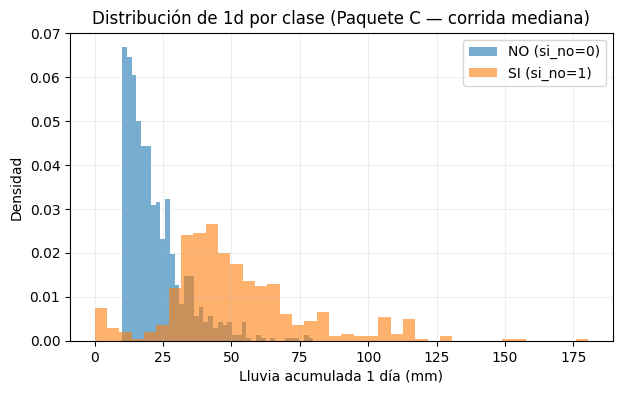

In [20]:
import matplotlib.pyplot as plt

col_1d = f"{T_DAYS}d"  # en tu caso: "1d"

# datos por clase
x0 = df_star.loc[df_star["si_no"] == 0, col_1d].dropna().to_numpy()
x1 = df_star.loc[df_star["si_no"] == 1, col_1d].dropna().to_numpy()

plt.figure(figsize=(7,4))
plt.hist(x0, bins=40, alpha=0.6, density=True, label="NO (si_no=0)")
plt.hist(x1, bins=40, alpha=0.6, density=True, label="SI (si_no=1)")
plt.xlabel("Lluvia acumulada 1 día (mm)")
plt.ylabel("Densidad")
plt.title("Distribución de 1d por clase (Paquete C — corrida mediana)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()


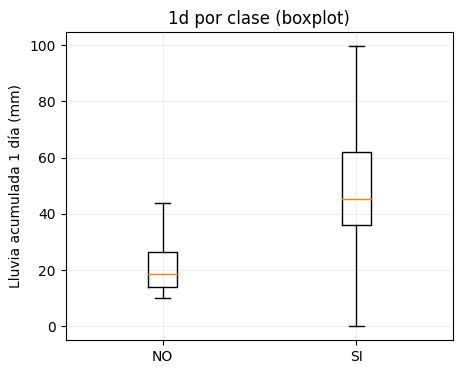

In [21]:
plt.figure(figsize=(5,4))
plt.boxplot([x0, x1], labels=["NO", "SI"], showfliers=False)
plt.ylabel("Lluvia acumulada 1 día (mm)")
plt.title("1d por clase (boxplot)")
plt.grid(True, alpha=0.2)
plt.show()

In [22]:
df_star.groupby("si_no")["1d"].describe()

,count,mean,std,min,25%,50%,75%,max
si_no,,,,,,,,
0,813.0,21.781583,10.987829,10.0,13.967773,18.541992,26.416016,80.009766
1,444.0,51.179548,25.946520,0.0,36.068359,45.212891,61.975586,180.339844


## **GRAFICOS DE LOS EFECTOS PARCIALES**

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CODIGO C (adaptado): T, P, slope_mean, DoY (sin/cos), ENSO, geologia, cobertura
# - NO grafica log_area
# - Logit usa DataFrame (con OneHotEncoder)
# - GAM usa array + CI (pyGAM)
# ============================================================

# ---------- labels ENSO ----------
ENSO_LABELS = {0: "La Niña", 1: "Neutro", 2: "El Niño"}

# ============================================================
# 1) LOGIT: helpers (DataFrame)
# ============================================================
def make_reference_point_df_C(X_df, strategy="median"):
    ref = {}
    num_cols = ["T", "P", "slope_mean", "log_area", "sin_doy", "cos_doy"]
    cat_cols = ["ENSO", "geologia", "cobertura"]

    if strategy == "median":
        for c in num_cols:
            ref[c] = float(np.nanmedian(X_df[c].to_numpy(float)))
    else:
        for c in num_cols:
            ref[c] = float(np.nanmean(X_df[c].to_numpy(float)))

    for c in cat_cols:
        ref[c] = X_df[c].mode(dropna=True).iloc[0]

    return ref

def proba1_df(model, X_df):
    p = np.asarray(model.predict_proba(X_df))
    return p[:, 1] if p.ndim == 2 else p

def curve_numeric_df_C(model, ref, var, grid):
    Xg = pd.DataFrame({k: [v]*len(grid) for k, v in ref.items()})
    Xg[var] = grid
    # asegurar strings para OneHotEncoder
    for c in ["ENSO", "geologia", "cobertura"]:
        Xg[c] = Xg[c].astype(str)
    return proba1_df(model, Xg)

def doy_curve_df_C(model, ref, doy_grid=np.arange(1, 366)):
    Xg = pd.DataFrame({k: [v]*len(doy_grid) for k, v in ref.items()})
    doy_rad = 2*np.pi*(doy_grid - 1)/365.0
    Xg["sin_doy"] = np.sin(doy_rad)
    Xg["cos_doy"] = np.cos(doy_rad)
    for c in ["ENSO", "geologia", "cobertura"]:
        Xg[c] = Xg[c].astype(str)
    return doy_grid, proba1_df(model, Xg)

def effect_categorical_df_C(model, ref, var, levels):
    Xg = pd.DataFrame({k: [v]*len(levels) for k, v in ref.items()})
    Xg[var] = levels
    for c in ["ENSO", "geologia", "cobertura"]:
        Xg[c] = Xg[c].astype(str)
    return np.array(levels), proba1_df(model, Xg)

def cov_label(x, cov_map):
    try:
        xi = int(float(str(x).strip()))
        return cov_map.get(str(xi), str(xi))
    except Exception:
        xs = str(x).strip()
        return cov_map.get(xs, xs)

def label_from_mapping(code, mapping):
    # code puede venir como 7, 7.0, "7", "7.0"
    try:
        c = int(float(str(code).strip()))
    except Exception:
        c = str(code).strip()

    # mapping puede tener llaves int o str
    return mapping.get(c, mapping.get(str(c), str(c)))

def _as_int_code(x):
    """Convierte 7, 7.0, '7', '7.0' -> 7; si no puede, devuelve None."""
    try:
        return int(float(str(x).strip()))
    except Exception:
        return None

def label_from_mapping_anykey(code, mapping, default=None):
    """
    Busca label en mapping tolerando llaves int/str y code int/float/str.
    """
    if mapping is None:
        return str(code) if default is None else default

    c = _as_int_code(code)
    # intenta con int
    if c is not None and c in mapping:
        return mapping[c]
    # intenta con str(int)
    if c is not None and str(c) in mapping:
        return mapping[str(c)]
    # intenta con str original
    s = str(code).strip()
    if s in mapping:
        return mapping[s]
    # intenta con str(float) típico '7.0'
    if c is not None and f"{float(c):.1f}" in mapping:
        return mapping[f"{float(c):.1f}"]

    return s if default is None else default


def plot_partial_effects_logit_C(
    logit,
    Xm_test,
    title="Logit — efectos parciales (C)",
    n_grid=200,
    cov_map=None,
    geo_map=None,
    top_k=10
):
    ref = make_reference_point_df_C(Xm_test, strategy="median")

    grids = {
        "T": np.linspace(np.percentile(Xm_test["T"], 1), np.percentile(Xm_test["T"], 99), n_grid),
        "P": np.linspace(np.percentile(Xm_test["P"], 1), np.percentile(Xm_test["P"], 99), n_grid),
        "slope_mean": np.linspace(np.percentile(Xm_test["slope_mean"], 1), np.percentile(Xm_test["slope_mean"], 99), n_grid),
    }

    top_geo  = Xm_test["geologia"].value_counts().head(top_k).index.astype(str).tolist()
    top_cov  = Xm_test["cobertura"].value_counts().head(top_k).index.astype(str).tolist()
    enso_levels = ["0", "1", "2"]

    if cov_map is None:
        cov_map = {
            "0": "Cultivos",
            "1": "Bosque Fragmentado",
            "2": "Canteras",
            "3": "Pastos",
            "4": "Cuerpos de agua",
            "5": "Pastos Arbolados",
            "6": "Pastos Enmalezados",
            "7": "Tejido Urbano Continuo",
            "8": "Tejido Urbano Discontinuo",
            "9": "Bosque Plantado",
            # alias comunes
            "Cultivos": "Cultivos",
            "Bosque Fragmentado.": "Bosque Fragmentado",
            "Tejido Urbano Continui": "Tejido Urbano Continuo",
            "Bosque Plantado.": "Bosque Plantado",
        }

    fig, axs = plt.subplots(2, 4, figsize=(13, 6))

    # numéricas: T, P, slope_mean
    for ax, var in zip(axs.ravel()[:3], ["T", "P", "slope_mean"]):
        p = curve_numeric_df_C(logit, ref, var, grids[var])
        ax.plot(grids[var], p)
        ax.set_xlabel(var)
        ax.set_ylabel("Probabilidad predicha")
        ax.grid(True, alpha=0.25)

    # DoY
    ax = axs.ravel()[3]
    doy_g, pD = doy_curve_df_C(logit, ref)
    ax.plot(doy_g, pD)
    ax.set_xlabel("Día del año (DoY)")
    ax.set_ylabel("Probabilidad predicha")
    ax.grid(True, alpha=0.25)

    # ENSO
    ax = axs.ravel()[4]
    levE, pE = effect_categorical_df_C(logit, ref, "ENSO", enso_levels)
    x = np.arange(len(levE))
    ax.plot(x, pE, "o")
    ax.set_xticks(x)
    ax.set_xticklabels([ENSO_LABELS.get(int(float(v)), str(v)) for v in levE], rotation=0)
    ax.set_xlabel("ENSO")
    ax.set_ylabel("Probabilidad predicha")
    ax.grid(True, alpha=0.25)

    # GEOLOGIA (top-k)  <-- antes era cobertura, ahora sí sale geología
    ax = axs.ravel()[5]
    levG, pG = effect_categorical_df_C(logit, ref, "geologia", top_geo)
    x = np.arange(len(levG))
    ax.plot(x, pG, "o")
    ax.set_xticks(x)
    if geo_map is None:
        ax.set_xticklabels(levG, rotation=45, ha="right")
    else:
        ax.set_xticklabels([label_from_mapping(g, geo_map) for g in levG], rotation=45, ha="right")
    ax.set_xlabel(f"geologia (top {top_k})")
    ax.set_ylabel("Probabilidad predicha")
    ax.grid(True, alpha=0.25)

        # COBERTURA (top-k)
    # COBERTURA (top-k)
    ax = axs.ravel()[6]
    levC, pC = effect_categorical_df_C(logit, ref, "cobertura", top_cov)
    x = np.arange(len(levC))
    ax.plot(x, pC, "o")
    ax.set_xticks(x)

    # usa label_from_mapping_anykey (sirve si cov_map tiene llaves int o str)
    ax.set_xticklabels([label_from_mapping_anykey(c, cov_map) for c in levC],
                    rotation=45, ha="right")

    ax.set_xlabel(f"cobertura (top {top_k})")
    ax.set_ylabel("Probabilidad predicha")
    ax.grid(True, alpha=0.25)


    # (opcional) apaga el último panel vacío para que no moleste
    axs.ravel()[7].axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    return fig, axs


# ============================================================
# 2) GAM: helpers (array + CI)
# ============================================================
def gam_proba_and_ci(gam, Xg, width=0.95):
    p = np.asarray(gam.predict_proba(Xg)).ravel()
    if hasattr(gam, "prediction_intervals"):
        ci = gam.prediction_intervals(Xg, width=width)
    elif hasattr(gam, "confidence_intervals"):
        ci = gam.confidence_intervals(Xg, width=width)
    else:
        raise AttributeError("Tu pyGAM no tiene prediction_intervals ni confidence_intervals (toca bootstrap).")
    return p, ci[:, 0], ci[:, 1]

def gam_curve_ci(gam, x_ref, var_idx, grid, width=0.95):
    Xtmp = np.tile(x_ref, (len(grid), 1))
    Xtmp[:, var_idx] = grid
    return gam_proba_and_ci(gam, Xtmp, width=width)

def gam_doy_curve_ci(gam, x_ref, sin_idx, cos_idx, doy_grid=np.arange(1, 366), width=0.95):
    Xtmp = np.tile(x_ref, (len(doy_grid), 1))
    doy_rad = 2*np.pi*(doy_grid - 1)/365.0
    Xtmp[:, sin_idx] = np.sin(doy_rad)
    Xtmp[:, cos_idx] = np.cos(doy_rad)
    p, lo, hi = gam_proba_and_ci(gam, Xtmp, width=width)
    return doy_grid, p, lo, hi

def gam_factor_ci(gam, x_ref, var_idx, codes, width=0.95):
    Xtmp = np.tile(x_ref, (len(codes), 1))
    Xtmp[:, var_idx] = np.array(codes, dtype=float)
    return gam_proba_and_ci(gam, Xtmp, width=width)



def plot_partial_effects_gam_C(
    gam,
    Xg_test,
    geo_code_to_name,
    cov_code_to_name,
    enso_code_to_name=None,
    title="GAM — efectos parciales (C)",
    n_grid=200,
    width=0.95,
    # IMPORTANTE: incluye log_area porque existe en X_gam
    feature_order=("T","P","sin_doy","cos_doy","ENSO","slope_mean","log_area","geologia","cobertura"),
    max_levels=12,
):
    feat = list(feature_order)
    idx = {name:i for i,name in enumerate(feat)}
    x_ref = np.median(Xg_test, axis=0)

    # grids numéricas (NO graficamos log_area, pero sí existe)
    T_grid = np.linspace(np.percentile(Xg_test[:, idx["T"]], 1), np.percentile(Xg_test[:, idx["T"]], 99), n_grid)
    P_grid = np.linspace(np.percentile(Xg_test[:, idx["P"]], 1), np.percentile(Xg_test[:, idx["P"]], 99), n_grid)
    S_grid = np.linspace(np.percentile(Xg_test[:, idx["slope_mean"]], 1), np.percentile(Xg_test[:, idx["slope_mean"]], 99), n_grid)

    fig, axs = plt.subplots(2, 4, figsize=(15, 6))

    # helpers de label robustos
    def label_from_mapping(code, mapping):
        c = int(code)
        return mapping.get(c, mapping.get(str(c), str(c)))

    # T
    ax = axs.ravel()[0]
    p, lo, hi = gam_curve_ci(gam, x_ref, idx["T"], T_grid, width=width)
    ax.plot(T_grid, p); ax.fill_between(T_grid, lo, hi, alpha=0.2)
    ax.set_xlabel("T (Corto plazo)"); ax.set_ylabel("Probabilidad predicha"); ax.grid(True, alpha=0.25)

    # P
    ax = axs.ravel()[1]
    p, lo, hi = gam_curve_ci(gam, x_ref, idx["P"], P_grid, width=width)
    ax.plot(P_grid, p); ax.fill_between(P_grid, lo, hi, alpha=0.2)
    ax.set_xlabel("P (Largo plazo)"); ax.set_ylabel("Probabilidad predicha"); ax.grid(True, alpha=0.25)

    # slope_mean
    ax = axs.ravel()[2]
    p, lo, hi = gam_curve_ci(gam, x_ref, idx["slope_mean"], S_grid, width=width)
    ax.plot(S_grid, p); ax.fill_between(S_grid, lo, hi, alpha=0.2)
    ax.set_xlabel("Pendiente (slope_mean)"); ax.set_ylabel("Probabilidad predicha"); ax.grid(True, alpha=0.25)

    # DoY
    ax = axs.ravel()[3]
    doy_g, pD, loD, hiD = gam_doy_curve_ci(gam, x_ref, idx["sin_doy"], idx["cos_doy"], width=width)
    ax.plot(doy_g, pD); ax.fill_between(doy_g, loD, hiD, alpha=0.2)
    ax.set_xlabel("Día del año (DoY)"); ax.set_ylabel("Probabilidad predicha"); ax.grid(True, alpha=0.25)

    # ENSO
    ax = axs.ravel()[4]
    enso_codes = [0, 1, 2]
    pE, loE, hiE = gam_factor_ci(gam, x_ref, idx["ENSO"], np.array(enso_codes, float), width=width)
    yerr = np.vstack([pE - loE, hiE - pE])

    ax.errorbar(np.arange(len(enso_codes)), pE, yerr=yerr,
                fmt="o", capsize=4, linestyle="none")

    # SIEMPRE usa ENSO_LABELS (no el mapping que trae '0','1','2')
    labelsE = [ENSO_LABELS[c] for c in enso_codes]
    ax.set_xticks(np.arange(len(enso_codes)))
    ax.set_xticklabels(labelsE)

    ax.set_xlabel("ENSO")
    ax.set_ylabel("Probabilidad predicha")
    ax.grid(True, alpha=0.25)

    # GEOLOGIA  ✅ (limitando niveles)
    ax = axs.ravel()[5]
    geo_codes = np.unique(Xg_test[:, idx["geologia"]].astype(int))[:max_levels]
    pG, loG, hiG = gam_factor_ci(gam, x_ref, idx["geologia"], geo_codes, width=width)
    yerr = np.vstack([pG - loG, hiG - pG])
    ax.errorbar(np.arange(len(geo_codes)), pG, yerr=yerr, fmt="o", capsize=4, linestyle="none")
    ax.set_xticks(np.arange(len(geo_codes)))
    ax.set_xticklabels([label_from_mapping(c, geo_code_to_name) for c in geo_codes], rotation=45, ha="right")
    ax.set_xlabel("geologia"); ax.set_ylabel("Probabilidad predicha"); ax.grid(True, alpha=0.25)

    # COBERTURA ✅ (limitando niveles)
    ax = axs.ravel()[6]
    cov_codes = np.unique(Xg_test[:, idx["cobertura"]].astype(int))[:max_levels]
    pC, loC, hiC = gam_factor_ci(gam, x_ref, idx["cobertura"], cov_codes, width=width)
    yerr = np.vstack([pC - loC, hiC - pC])
    ax.errorbar(np.arange(len(cov_codes)), pC, yerr=yerr, fmt="o", capsize=4, linestyle="none")
    ax.set_xticks(np.arange(len(cov_codes)))
    ax.set_xticklabels([label_from_mapping(c, cov_code_to_name) for c in cov_codes], rotation=45, ha="right")
    ax.set_xlabel("cobertura"); ax.set_ylabel("Probabilidad predicha"); ax.grid(True, alpha=0.25)

    # panel 8 vacío (porque no graficamos log_area)
    axs.ravel()[7].axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    return fig, axs

cov_names = {
    0: "Cultivos",
    1: "Bosque Fragmentado",
    2: "Canteras",
    3: "Pastos",
    4: "Cuerpos de agua",
    5: "Pastos Arbolados",
    6: "Pastos Enmalezados",
    7: "Tejido Urbano Continuo",
    8: "Tejido Urbano Discontinuo",
    9: "Bosque Plantado",
}

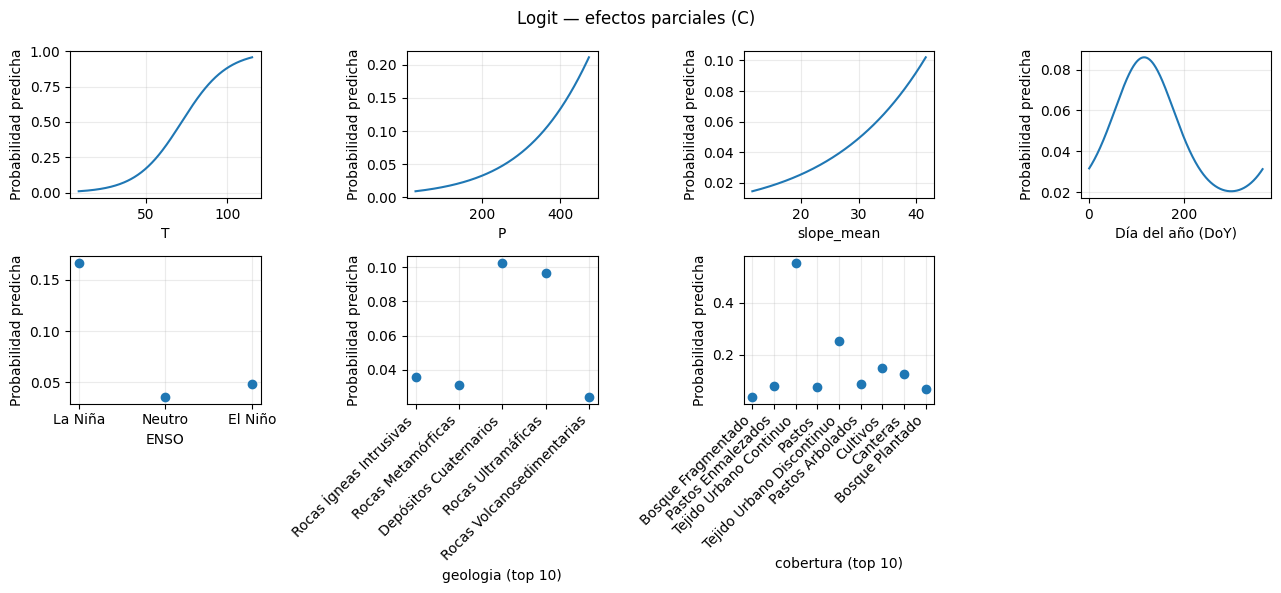

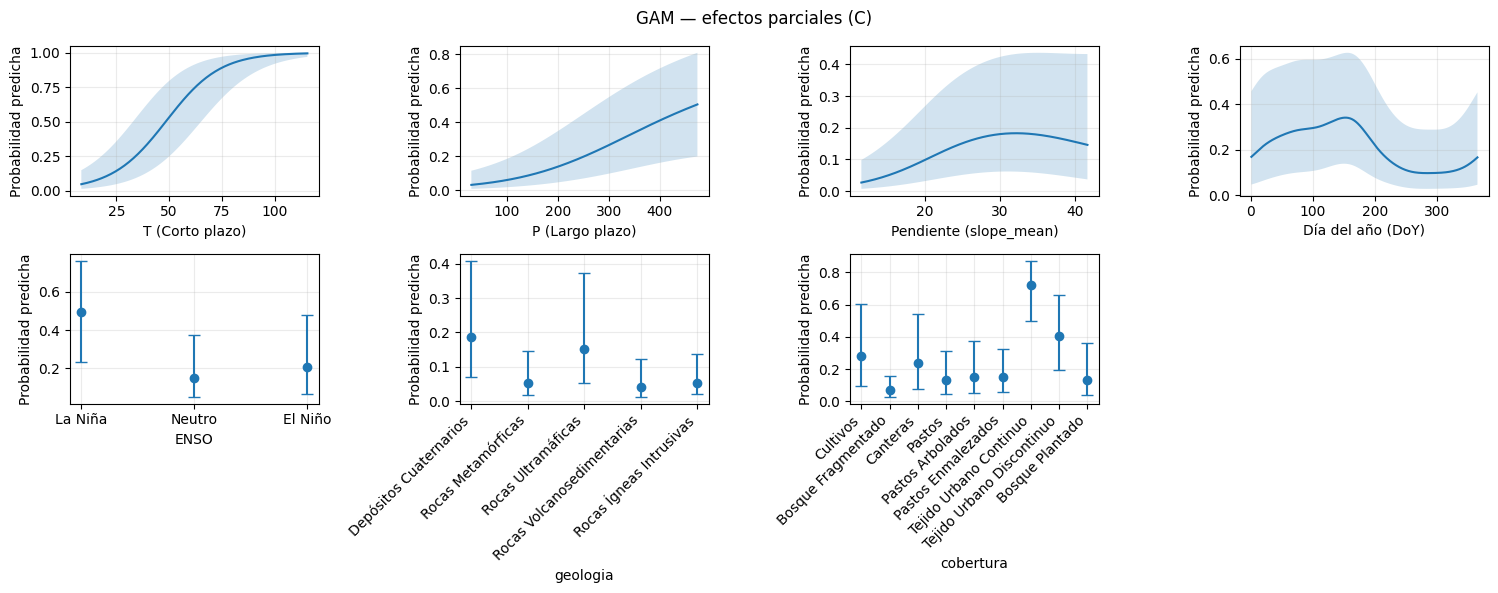

In [24]:
plot_partial_effects_logit_C(
    logit, Xm_te,
    title="Logit — efectos parciales (C)",
    geo_map=geo_map,     # si tienes códigos->nombres
    cov_map=cov_names
)

plot_partial_effects_gam_C(
    gam, Xg_te,
    geo_code_to_name=geo_map,
    cov_code_to_name=cov_names,   # <- aquí
)
plt.show()


## **GRAFICOS DE LA IMPORTANCIA DE LAS VARIABLES**

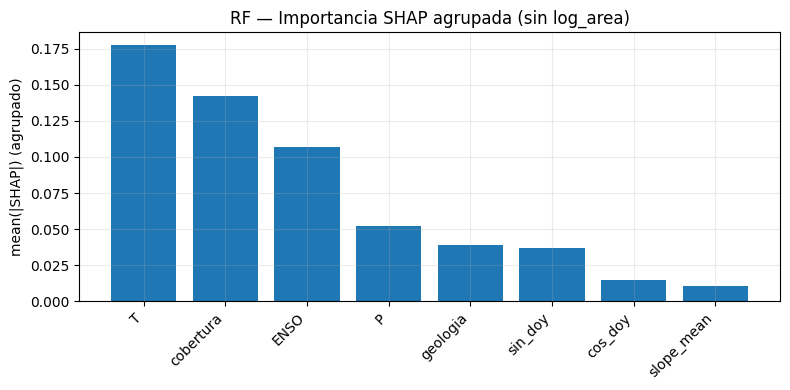

      feature  mean_abs_shap
0           T       0.177453
7   cobertura       0.142289
5        ENSO       0.107155
1           P       0.052482
6    geologia       0.038776
2     sin_doy       0.037279
3     cos_doy       0.014848
4  slope_mean       0.010483


In [25]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# ============================================================
# SHAP RF (Pipeline) — Paquete C
# 1) SIN log_area
# 2) Importancia AGRUPADA por variable original:
#    - ENSO (todas sus dummies juntas)
#    - geologia (todas juntas)
#    - cobertura (todas juntas)
#    - y numéricas individuales (T,P,sin_doy,cos_doy,slope_mean)
# ============================================================

def shap_rf_grouped_C(
    rf_pipe,
    Xm_test,
    num_cols=("T","P","sin_doy","cos_doy","slope_mean"),   # <- sin log_area
    cat_cols=("ENSO","geologia","cobertura"),
    top_k=25,
    max_display=25,
    plot_dot=False,   # si True: dot plot (dummies). si False: solo agrupado
):
    prep = rf_pipe.named_steps["prep"]
    clf  = rf_pipe.named_steps["clf"]

    Xm = Xm_test.copy()
    for c in cat_cols:
        Xm[c] = Xm[c].astype(str)

    # 1) Transformación post-prep (incluye one-hot)
    X_trans = prep.transform(Xm)

    # 2) Nombres post one-hot (para agrupar)
    ohe = prep.named_transformers_["cat"]
    cat_names = ohe.get_feature_names_out(list(cat_cols))
    feat_out = np.concatenate([np.array(list(num_cols)), cat_names])

    # 3) SHAP sobre el modelo real
    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_trans)
    shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

    # 4) (Opcional) dot plot con dummies (NO agrupado)
    if plot_dot:
        X_df = pd.DataFrame(X_trans, columns=feat_out)
        shap.summary_plot(shap_vals, X_df, plot_type="dot", max_display=max_display, show=True)

    # ========================================================
    # 5) Agrupar: sum(|SHAP|) de todas las columnas de cada variable original
    # ========================================================
    abs_shap = np.abs(shap_vals)

    # índices de numéricas (ya están 1:1)
    groups = {c: [i] for i, c in enumerate(num_cols)}

    # índices de categóricas (todas sus dummies juntas)
    start_cat = len(num_cols)
    for j, name in enumerate(cat_names):
        # name típico: "cobertura_7.0" o "ENSO_2"
        prefix = name.split("_", 1)[0]   # "cobertura" / "geologia" / "ENSO"
        idx_col = start_cat + j
        groups.setdefault(prefix, []).append(idx_col)

    # importancia global por grupo (media de sum(|shap|) por fila)
    grouped_imp = {
        g: float(abs_shap[:, idxs].sum(axis=1).mean())
        for g, idxs in groups.items()
    }

    imp_df = (pd.DataFrame({"feature": list(grouped_imp.keys()),
                            "mean_abs_shap": list(grouped_imp.values())})
                .sort_values("mean_abs_shap", ascending=False))

    # 6) Plot agrupado (barra)
    plt.figure(figsize=(8, 4))
    plt.bar(imp_df["feature"].head(top_k), imp_df["mean_abs_shap"].head(top_k))
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("mean(|SHAP|) (agrupado)")
    plt.title("RF — Importancia SHAP agrupada (sin log_area)")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    return imp_df, groups

# Uso:
imp_grouped_C, groups_C = shap_rf_grouped_C(rf, Xm_te, plot_dot=False)
print(imp_grouped_C)



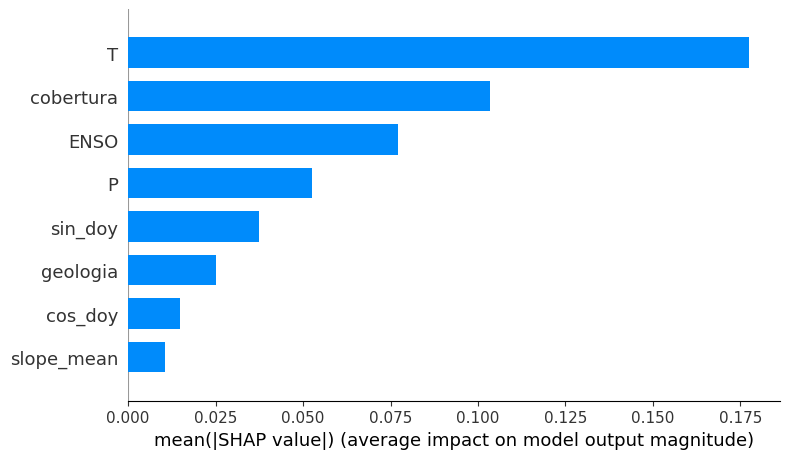

In [26]:
import numpy as np
import pandas as pd
import shap

def shap_summary_rf_grouped_pipeline_C(
    rf_pipe,
    Xm_test,
    num_cols=("T","P","sin_doy","cos_doy","slope_mean"),   # <- sin log_area
    cat_cols=("ENSO","geologia","cobertura"),
    plot="bar",                 # "bar" o "dot"
    max_display=20,
    show=True,
):
    prep = rf_pipe.named_steps["prep"]
    clf  = rf_pipe.named_steps["clf"]

    Xm = Xm_test.copy()
    for c in cat_cols:
        Xm[c] = Xm[c].astype(str)

    # 1) Transformación post-onehot (lo que realmente ve el RF)
    X_trans = prep.transform(Xm)

    # 2) nombres post one-hot
    ohe = prep.named_transformers_["cat"]
    cat_names = ohe.get_feature_names_out(list(cat_cols))
    feat_out = np.concatenate([np.array(list(num_cols)), cat_names])

    # 3) SHAP del RF
    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_trans)
    shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

    # ============================================================
    # 4) Agrupar columnas one-hot por variable original
    # ============================================================
    start_cat = len(num_cols)

    groups = {c: [i] for i, c in enumerate(num_cols)}  # numéricas 1:1

    for j, name in enumerate(cat_names):
        # típico: "cobertura_7.0" / "ENSO_2" / "geologia_3"
        prefix = name.split("_", 1)[0]
        groups.setdefault(prefix, []).append(start_cat + j)

    group_names = list(groups.keys())

    # SHAP agrupado (con signo): suma de shap de sus columnas
    shap_grouped = np.column_stack([shap_vals[:, groups[g]].sum(axis=1) for g in group_names])

    # Valores de features para el plot:
    # - para bar plot, esto casi no importa
    # - para dot plot, sí: usamos valores "originales" (num) y códigos (cat)
    Xg = pd.DataFrame(index=Xm.index)
    for g in group_names:
        if g in num_cols:
            Xg[g] = Xm[g].to_numpy(float)
        else:
            # códigos numéricos para que SHAP pueda hacer beeswarm
            Xg[g] = pd.Categorical(Xm[g].astype(str)).codes.astype(float)

    # ============================================================
    # 5) Plot con SHAP
    # ============================================================
    shap.summary_plot(
        shap_grouped,
        features=Xg,
        feature_names=group_names,
        plot_type=plot,            # "bar" o "dot"
        max_display=max_display,
        show=show
    )

    return shap_grouped, Xg, group_names, groups

# USO:
# - Gráfico recomendado: barras agrupadas (una sola ENSO/geologia/cobertura)
shap_grouped, Xg_grouped, group_names, groups = shap_summary_rf_grouped_pipeline_C(
    rf, Xm_te, plot="bar", max_display=20, show=True
)

# - Si quieres beeswarm agrupado:
# shap_summary_rf_grouped_pipeline_C(rf, Xm_te, plot="dot", max_display=20, show=True)


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import roc_auc_score

# ============================================================
# PAQUETE C — Importancia por permutación (ΔAUROC) para GAM y Logit
# - Logit: permuta columnas originales del DataFrame (T,P,sin,cos,slope,ENSO,geologia,cobertura)
# - GAM: permuta columnas del array Xg_te (orden: T,P,sin,cos,ENSO,slope,log_area,geologia,cobertura)
# - Plot: puntos + CI (p2.5–p97.5) y mediana (como en tu guía)
# ============================================================

# -------------------------
# Helpers pred proba clase 1
# -------------------------
def _proba1(model, X):
    p = np.asarray(model.predict_proba(X))
    return p[:, 1] if p.ndim == 2 else p

# -------------------------
# Permutation importance (ARRAY: GAM)
# -------------------------
def permutation_importance_auc_drop_array(
    model, X_test_arr, y_test, feature_names, n_perm=100, seed=0
):
    rng = np.random.default_rng(seed)
    auc_base = roc_auc_score(y_test, _proba1(model, X_test_arr))

    drops_all = {}
    for j, name in enumerate(feature_names):
        drops = np.zeros(n_perm, dtype=float)
        for k in range(n_perm):
            Xp = X_test_arr.copy()
            Xp[:, j] = rng.permutation(Xp[:, j])
            auc_p = roc_auc_score(y_test, _proba1(model, Xp))
            drops[k] = auc_base - auc_p
        drops_all[name] = drops

    drops_mean = {v: float(np.mean(a)) for v, a in drops_all.items()}
    drops_ci   = {v: (float(np.quantile(a, 0.025)), float(np.quantile(a, 0.975))) for v, a in drops_all.items()}
    return drops_mean, drops_ci, drops_all

# -------------------------
# Permutation importance (DF: Logit Pipeline)
#   IMPORTANTE: se clona el pipeline para que no cambie estado.
#   Para columnas categóricas, permutamos los labels (strings).
# -------------------------
def permutation_importance_auc_drop_df(
    model, X_test_df, y_test, feature_names, n_perm=100, seed=0
):
    rng = np.random.default_rng(seed)
    auc_base = roc_auc_score(y_test, _proba1(model, X_test_df))

    drops_all = {}
    for name in feature_names:
        drops = np.zeros(n_perm, dtype=float)
        for k in range(n_perm):
            Xp = X_test_df.copy()
            Xp[name] = rng.permutation(Xp[name].to_numpy())
            auc_p = roc_auc_score(y_test, _proba1(model, Xp))
            drops[k] = auc_base - auc_p
        drops_all[name] = drops

    drops_mean = {v: float(np.mean(a)) for v, a in drops_all.items()}
    drops_ci   = {v: (float(np.quantile(a, 0.025)), float(np.quantile(a, 0.975))) for v, a in drops_all.items()}
    return drops_mean, drops_ci, drops_all

# -------------------------
# Convertir resultados a DataFrame "tidy"
# -------------------------
def importance_records(model_name, drops_mean, drops_ci):
    recs = []
    for feat in drops_mean:
        lo, hi = drops_ci[feat]
        recs.append({
            "modelo": model_name,
            "variable": feat,
            "auc_drop_mean": float(drops_mean[feat]),
            "auc_drop_p025": float(lo),
            "auc_drop_p975": float(hi),
        })
    return recs

# -------------------------
# Plot: dot + CI (mediana) por variable
# -------------------------
def plot_importance_dot_ci(imp_df, model_name, title=None):
    d = imp_df[imp_df["modelo"] == model_name].copy()

    g = d.groupby("variable").agg(
        mean_drop=("auc_drop_mean", "median"),
        lo=("auc_drop_p025", "median"),
        hi=("auc_drop_p975", "median"),
    ).reset_index().sort_values("mean_drop")

    y = np.arange(len(g))
    fig, ax = plt.subplots(figsize=(7.5, 3.4))
    ax.hlines(y, g["lo"], g["hi"], linewidth=2)
    ax.plot(g["mean_drop"], y, "o", markersize=7)
    ax.set_yticks(y)
    ax.set_yticklabels(g["variable"])
    ax.set_xlabel("Importancia (ΔAUROC tras permutar)")
    ax.set_title(title or f"Permutation importance — {model_name}")
    ax.grid(True, axis="x", alpha=0.25)
    plt.tight_layout()
    return fig, ax

# ============================================================
# FUNCIÓN PRINCIPAL (Paquete C)
# ============================================================
def permutation_importance_models_C(
    gam, logit, Xg_te, Xm_te, y_te,
    n_perm=100, seed_perm=123,
    feature_names_gam=("T","P","sin_doy","cos_doy","ENSO","slope_mean","log_area","geologia","cobertura"),
    feature_names_logit=("T","P","sin_doy","cos_doy","slope_mean","log_area","ENSO","geologia","cobertura"),
    drop_log_area_plot=False,   # si quieres ocultarla en el plot (pero se puede calcular igual)
):
    # 1) GAM (array)
    drops_gam_mean, drops_gam_ci, _ = permutation_importance_auc_drop_array(
        gam, Xg_te, y_te, list(feature_names_gam), n_perm=n_perm, seed=seed_perm
    )

    # 2) Logit (pipeline)
    drops_logit_mean, drops_logit_ci, _ = permutation_importance_auc_drop_df(
        logit, Xm_te, y_te, list(feature_names_logit), n_perm=n_perm, seed=seed_perm
    )

    # 3) armar DF
    recs = []
    recs += importance_records("GAM", drops_gam_mean, drops_gam_ci)
    recs += importance_records("Logit", drops_logit_mean, drops_logit_ci)
    imp_df = pd.DataFrame(recs)

    # 4) opcional: quitar log_area del df SOLO para graficar
    if drop_log_area_plot:
        imp_df_plot = imp_df[imp_df["variable"] != "log_area"].copy()
    else:
        imp_df_plot = imp_df

    return imp_df, imp_df_plot


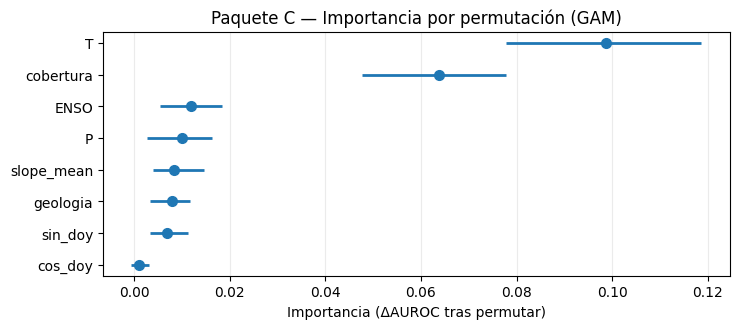

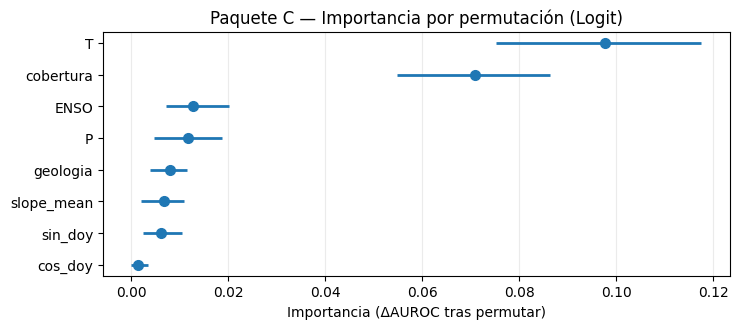

In [28]:
# ============================================================
# USO (ya tienes: gam, logit, Xg_te, Xm_te, y_te)
# ============================================================

# OJO: en tu build_TP_dataset_allvars el orden del GAM es:
# [T, P, sin, cos, enso_factor, slope, log_area, geo_factor, cov_factor]
FEATURE_NAMES_GAM_C   = ("T","P","sin_doy","cos_doy","ENSO","slope_mean","log_area","geologia","cobertura")

# En el DataFrame del ML tienes:
# ["T","P","sin_doy","cos_doy","ENSO","slope_mean","log_area","geologia","cobertura"]
# Para permutar, el orden NO importa, solo que existan esas columnas.
FEATURE_NAMES_LOGIT_C = ("T","P","sin_doy","cos_doy","slope_mean","log_area","ENSO","geologia","cobertura")

imp_df, imp_df_plot = permutation_importance_models_C(
    gam, logit, Xg_te, Xm_te, y_te,
    n_perm=100, seed_perm=123,
    feature_names_gam=FEATURE_NAMES_GAM_C,
    feature_names_logit=FEATURE_NAMES_LOGIT_C,
    drop_log_area_plot=True  # <- si NO quieres mostrarla en el gráfico
)

# Graficar
plot_importance_dot_ci(imp_df_plot, "GAM",  title="Paquete C — Importancia por permutación (GAM)")
plot_importance_dot_ci(imp_df_plot, "Logit", title="Paquete C — Importancia por permutación (Logit)")
plt.show()


## **UMBRALES CON CURVA ROC**

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

def roc_threshold_points(y_true, y_prob, tpr_targets=(0.95, 0.25)):
    """
    Calcula ROC y extrae umbrales tipo paper:
    - TPR95: umbral con TPR ~ 0.95
    - OPT: Youden max (TPR - FPR)
    - TPR25: umbral con TPR ~ 0.25

    Retorna:
      auc, fpr, tpr, thr,
      dict puntos: {name: {thr, tpr, fpr, tnr, specificity}}
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    fpr, tpr, thr = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    # --- OPT (Youden) ---
    j = tpr - fpr
    i_opt = int(np.argmax(j))

    # --- TPR targets (closest) ---
    def closest_tpr(target):
        i = int(np.argmin(np.abs(tpr - target)))
        return i

    i_95 = closest_tpr(tpr_targets[0])
    i_25 = closest_tpr(tpr_targets[1])

    pts = {
        "TPR95": {
            "prob": float(thr[i_95]),
            "TPR": float(tpr[i_95]),
            "FPR": float(fpr[i_95]),
            "TNR": float(1 - fpr[i_95]),
            "Specificity": float(1 - fpr[i_95]),
        },
        "OPT": {
            "prob": float(thr[i_opt]),
            "TPR": float(tpr[i_opt]),
            "FPR": float(fpr[i_opt]),
            "TNR": float(1 - fpr[i_opt]),
            "Specificity": float(1 - fpr[i_opt]),
        },
        "TPR25": {
            "prob": float(thr[i_25]),
            "TPR": float(tpr[i_25]),
            "FPR": float(fpr[i_25]),
            "TNR": float(1 - fpr[i_25]),
            "Specificity": float(1 - fpr[i_25]),
        },
    }
    return auc, fpr, tpr, thr, pts


def plot_roc_like_paper(y_true, y_prob, title="ROC", show_points=True):
    """
    Grafica ROC en formato paper: x=Specificity (1->0), y=Sensitivity.
    """
    auc, fpr, tpr, thr, pts = roc_threshold_points(y_true, y_prob)

    specificity = 1 - fpr

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(specificity, tpr, lw=2)  # curva ROC

    # Diagonal de azar en espacio (Specificity, Sensitivity): (1,0) -> (0,1)
    ax.plot([1, 0], [0, 1], lw=1)

    ax.set_xlim(1.0, 0.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Specificity")
    ax.set_ylabel("Sensitivity")
    ax.set_title(f"{title}  |  AUROC = {auc:.3f}")

    if show_points:
        for name in ["TPR95", "OPT", "TPR25"]:
            x = pts[name]["Specificity"]
            y = pts[name]["TPR"]
            ax.scatter([x], [y], s=70)
            ax.text(
                x, y,
                f" {name}\n p={pts[name]['prob']:.3f}\n TPR={pts[name]['TPR']*100:.1f}%\n TNR={pts[name]['TNR']*100:.1f}%",
                va="center"
            )

    ax.grid(True, alpha=0.2)
    plt.show()

    return auc, pts


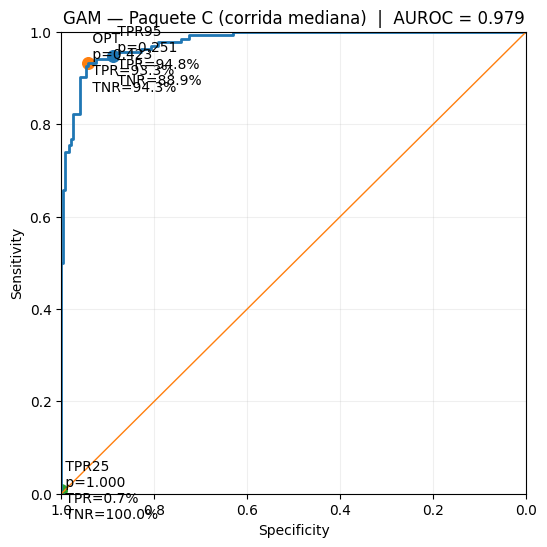

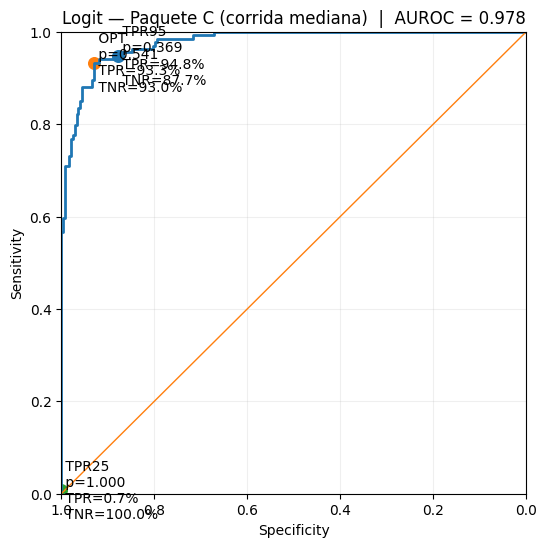

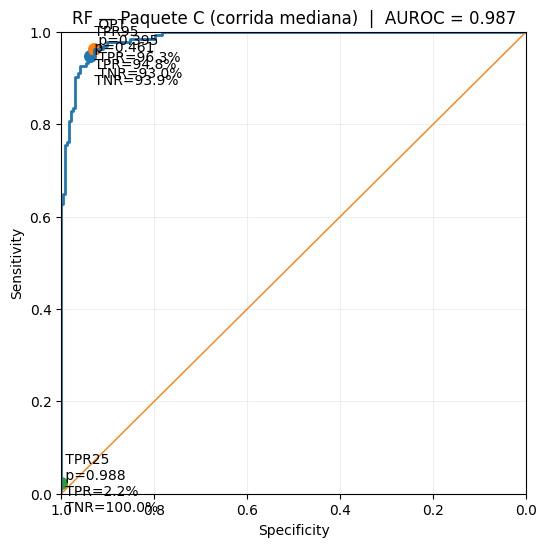

GAM
            prob       TPR       FPR       TNR  Specificity
TPR95  0.251454  0.947761  0.110656  0.889344     0.889344
OPT    0.423145  0.932836  0.057377  0.942623     0.942623
TPR25  0.999994  0.007463  0.000000  1.000000     1.000000 

Logit
            prob       TPR       FPR       TNR  Specificity
TPR95  0.369292  0.947761  0.122951  0.877049     0.877049
OPT    0.540703  0.932836  0.069672  0.930328     0.930328
TPR25  0.999992  0.007463  0.000000  1.000000     1.000000 

RF
            prob       TPR       FPR       TNR  Specificity
TPR95  0.460997  0.947761  0.061475  0.938525     0.938525
OPT    0.394722  0.962687  0.069672  0.930328     0.930328
TPR25  0.987533  0.022388  0.000000  1.000000     1.000000 



In [30]:
# Probabilidades en test
p_gam   = gam.predict_proba(Xg_te)
p_logit = logit.predict_proba(Xm_te)[:, 1]
p_rf    = rf.predict_proba(Xm_te)[:, 1]

# 1) ROC como el paper (elige el modelo que quieras)
auc_gam,  pts_gam  = plot_roc_like_paper(y_te, p_gam,   title="GAM — Paquete C (corrida mediana)")
auc_log,  pts_log  = plot_roc_like_paper(y_te, p_logit, title="Logit — Paquete C (corrida mediana)")
auc_rf,   pts_rf   = plot_roc_like_paper(y_te, p_rf,    title="RF — Paquete C (corrida mediana)")

# 2) Imprimir los números tipo Fig. 10
import pandas as pd
print("GAM\n",  pd.DataFrame(pts_gam).T, "\n")
print("Logit\n",pd.DataFrame(pts_log).T, "\n")
print("RF\n",   pd.DataFrame(pts_rf).T, "\n")


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def aggregate_roc_p5_p95(roc_df, modelo, n_grid=401):
    """
    Agrega curvas ROC por Monte Carlo:
    - Interpola TPR sobre una malla común de FPR
    - Devuelve mediana y banda p5–p95 (por TPR)
    """
    grid_fpr = np.linspace(0, 1, n_grid)

    tprs = []
    sub = roc_df[roc_df["modelo"] == modelo].copy()

    for mc_id, g in sub.groupby("mc_id"):
        g = g.sort_values("fpr")
        fpr = g["fpr"].to_numpy()
        tpr = g["tpr"].to_numpy()

        # Seguridad: si por empates hay puntos repetidos, hacemos unique en fpr
        fpr_u, idx_u = np.unique(fpr, return_index=True)
        tpr_u = tpr[idx_u]

        # Interpolación
        tpr_i = np.interp(grid_fpr, fpr_u, tpr_u)
        tprs.append(tpr_i)

    tprs = np.vstack(tprs)  # (n_mc, n_grid)

    tpr_med = np.median(tprs, axis=0)
    tpr_p05 = np.quantile(tprs, 0.05, axis=0)
    tpr_p95 = np.quantile(tprs, 0.95, axis=0)

    spec = 1.0 - grid_fpr  # Specificity
    return spec, tpr_med, tpr_p05, tpr_p95


def summarize_points_p5_p95(thr_df, modelo):
    """
    Para cada punto (OPT, TPR25, TPR95):
    retorna mediana y p5/p95 de (TNR, TPR) y de threshold.
    """
    sub = thr_df[thr_df["modelo"] == modelo].copy()

    rows = []
    for name, g in sub.groupby("name"):
        tnr = g["tnr"].to_numpy()
        tpr = g["tpr"].to_numpy()
        thr = g["threshold"].to_numpy()

        rows.append({
            "name": name,
            "tnr_med": float(np.median(tnr)),
            "tnr_p05": float(np.quantile(tnr, 0.05)),
            "tnr_p95": float(np.quantile(tnr, 0.95)),
            "tpr_med": float(np.median(tpr)),
            "tpr_p05": float(np.quantile(tpr, 0.05)),
            "tpr_p95": float(np.quantile(tpr, 0.95)),
            "thr_med": float(np.median(thr)),
            "thr_p05": float(np.quantile(thr, 0.05)),
            "thr_p95": float(np.quantile(thr, 0.95)),
            "n_mc": int(len(g))
        })

    # Orden bonito: TPR95, OPT, TPR25 (como tu figura típica)
    order = {"TPR95": 0, "OPT": 1, "TPR25": 2}
    rows = sorted(rows, key=lambda r: order.get(r["name"], 99))
    return pd.DataFrame(rows)

def plot_roc_with_band_and_points(roc_df, thr_df, modelo, n_grid=401, title=None):
    spec, tpr_med, tpr_p05, tpr_p95 = aggregate_roc_p5_p95(roc_df, modelo, n_grid=n_grid)
    pts = summarize_points_p5_p95(thr_df, modelo)

    fig, ax = plt.subplots(figsize=(7, 6))

    # Banda p5–p95
    ax.fill_between(spec, tpr_p05, tpr_p95, alpha=0.25)

    # Curva mediana
    ax.plot(spec, tpr_med, linewidth=2)

    # Diagonal “azar” (en espacio Specificity–TPR)
    # En ROC usual es TPR vs FPR; aquí x=1-FPR, entonces la diagonal es TPR = 1 - Specificity
    x = np.linspace(0, 1, 200)
    ax.plot(x, 1 - x, linewidth=1)

    # Puntos con barras p5–p95
    for _, r in pts.iterrows():
        x_med = r["tnr_med"]
        y_med = r["tpr_med"]
        xerr = [[x_med - r["tnr_p05"]], [r["tnr_p95"] - x_med]]
        yerr = [[y_med - r["tpr_p05"]], [r["tpr_p95"] - y_med]]

        ax.errorbar(
            x_med, y_med,
            xerr=xerr, yerr=yerr,
            fmt='o', capsize=3
        )

        # Etiqueta con threshold mediano (prob)
        # ax.annotate(
        #     f'{r["name"]}\nProb {r["thr_med"]:.3f}\nTPR {100*r["tpr_med"]:.1f}%\nTNR {100*r["tnr_med"]:.1f}%',
        #     (x_med, y_med),
        #     textcoords="offset points",
        #     xytext=(8, -10),
        #     ha="left"
        # )

    ax.set_xlabel("Specificity (TNR)")
    ax.set_ylabel("Sensitivity (TPR)")
    ax.set_xlim(1.0, 0.0)          # como tu figura: de 1 a 0
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.3)
    if title is None:
        title = f"ROC agregada (mediana + p5–p95) — {modelo}"
    ax.set_title(title)

    plt.tight_layout()
    return fig, ax, pts




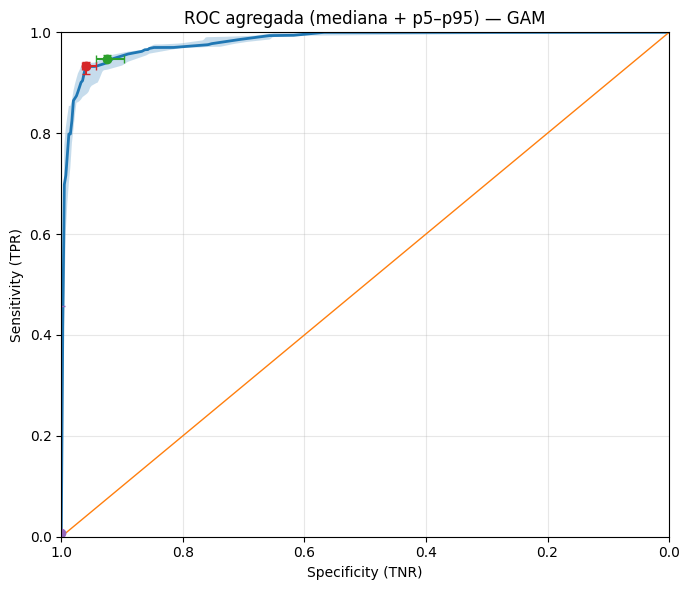

    name  tnr_med   tnr_p05   tnr_p95   tpr_med   tpr_p05   tpr_p95   thr_med  \
0  TPR95    0.924  0.897265  0.943503  0.947761  0.947368  0.954887  0.374497   
1    OPT    0.960  0.943548  0.966375  0.932331  0.917293  0.940209  0.505690   
2  TPR25    1.000  1.000000  1.000000  0.007519  0.007519  0.458097  0.999978   

    thr_p05   thr_p95  n_mc  
0  0.335653  0.438372     5  
1  0.491918  0.568002     5  
2  0.982229  0.999992     5  


In [7]:
roc_path = "/home/oisanchezp/Thesis/data/processed/roc_curves_paquetec_T1_P33_MC100.csv"
thr_path = "/home/oisanchezp/Thesis/data/processed/roc_threshold_points_paquetec_T1_P33_MC100.csv"

roc_df = pd.read_csv(roc_path)
thr_df = pd.read_csv(thr_path)

fig, ax, pts_gam = plot_roc_with_band_and_points(roc_df, thr_df, modelo="GAM")
plt.show()

# Si quieres guardar:
#fig.savefig("/home/oisanchezp/Thesis/data/processed/fig_roc_gam_paquetec.png", dpi=300)

# Ver tabla de puntos (mediana y bandas):
print(pts_gam)
